# Progetto finale - notebook 1

## Organizzazione dataset

In [21]:
import numpy as np 
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import json

from pathlib import Path
from shapely.geometry import Point
from shapely.geometry import shape

# importazione del modulo con le funzioni
%load_ext autoreload
%autoreload 2
import sys
sys.path.append('..')

from IPython.display import Image, display
import functions.EDA_funcs as fs

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
data_path_raw = Path('../data/raw')
data_path_ext = Path('../data/external')

files_raw = {'grid':'trentino-grid.geojson',
         'adm_reg':'ondata_confini_amministrativi_api_v2_it_20120101_unita-territoriali-sovracomunali_22_comuni.geo.json',
         'weather':'meteotrentino-weather-station-data.json',
         'precip':'precipitation-trentino.csv',
         'precip-avail':'precipitation-trentino-data-availability.csv',
         'SET-1':'SET-nov-2013.csv',
         'SET-2':'SET-dec-2013.csv',
         'SET-lines':'line.csv',
         'twitter':'social-pulse-trentino.geojson'}

files_ext = {'data_pol':'APPA_extended.csv',
              'pos':'posizioni_stazioni_appa.csv'}

In [23]:
# importiamo la griglia con la geometria delle celle
grid_df = gpd.read_file(data_path_raw / files_raw['grid'])

### MeteoTrentino, ARPA

In [24]:
with open(data_path_raw / files_raw['weather']) as f:
    weather_json = json.load(f)

weather = gpd.GeoDataFrame(weather_json['features'])

weather = fs.fill_hole(weather)

# splittiamo le colonne del vento in speed e direction
weather_df = fs.winds_split(weather)

weather_df['geometry'] = weather_df['geomPoint.geom'].apply(lambda x:Point(x['coordinates'][0], x['coordinates'][1]))
weather_df.drop(columns=['geomPoint.geom'],inplace=True)

# modifichiamo il dataframe weather in modo che sia nella stessa forma degli altri dataframe
weather_df = fs.restructure_weather(weather_df)

weather_df.head()

,station,date,hour,elevation,temperature,precipitation,winds_spd,winds_dir,geometry
0,T0071,2013-11-01,0,905,8.4,0.0,0.1,205.0,POINT (10.79583 46.3134)
1,T0071,2013-11-01,1,905,8.2,0.0,0.5,231.0,POINT (10.79583 46.3134)
2,T0071,2013-11-01,2,905,8.0,0.0,0.0,294.0,POINT (10.79583 46.3134)
3,T0071,2013-11-01,3,905,7.8,0.0,0.5,273.0,POINT (10.79583 46.3134)
4,T0071,2013-11-01,4,905,6.6,0.0,0.1,274.0,POINT (10.79583 46.3134)


### APPA

In [25]:
appa_df = pd.read_csv(data_path_ext / files_ext['data_pol'], encoding='latin1')

# convertiamo gli elementi nelle colonne 'Valore' e 'Ora' in valori numerici
appa_df['Valore'] = pd.to_numeric(appa_df['Valore'], errors='coerce')
appa_df['Ora'] = pd.to_numeric(appa_df['Ora'], errors='coerce')

In [26]:
# a partire da appa_pos, creiamo la colonna 'geometry' per appa_df.
appa_pos = pd.read_csv(data_path_ext / files_ext['pos'])

appa_pos['geometry'] = appa_pos['Posizione'].apply(lambda x:Point(float(x.split(',')[1]),float(x.split(',')[0])))

data_names = ['Piana Rotaliana', 'Riva del Garda', 'Monte Gaza', 'Parco S. Chiara', 'Rovereto', 'Via Bolzano','A22 (Avio)', 'Borgo Valsugana']

appa_pos['station'] = data_names

appa_df['geometry'] = appa_df['Stazione'].map(appa_pos.set_index('station')['geometry'])

# cambiamo i nomi delle colonne di inquinanti
appa_df['Inquinante'] = appa_df['Inquinante'].replace({'Biossido Zolfo': 'SO2', 'Biossido di Azoto': 'NO2', 'Ossido di Carbonio': 'CO', 'Ozono': 'O3'})

appa_df.head()

,Stazione,Inquinante,Data,Ora,Valore,Unità di misura,geometry
0,Parco S. Chiara,PM10,2013-11-01,1,23.0,µg/mc,POINT (11.1262 46.06292)
1,Parco S. Chiara,PM10,2013-11-01,2,25.0,µg/mc,POINT (11.1262 46.06292)
2,Parco S. Chiara,PM10,2013-11-01,3,23.0,µg/mc,POINT (11.1262 46.06292)
3,Parco S. Chiara,PM10,2013-11-01,4,21.0,µg/mc,POINT (11.1262 46.06292)
4,Parco S. Chiara,PM10,2013-11-01,5,20.0,µg/mc,POINT (11.1262 46.06292)


In [27]:
# spostiamo gli inquinanti su diverse colonne per facilitare il confronto
appa_df['Valore'] = pd.to_numeric(appa_df['Valore'], errors='coerce')
appa_comp_df = appa_df.pivot_table(index=['Stazione', 'Data', 'Ora'],columns='Inquinante', values='Valore').reset_index()
appa_comp_df.columns.name = None
appa_comp_df['geometry'] = appa_comp_df['Stazione'].map(appa_pos.set_index('station')['geometry'])
appa_comp_df = appa_comp_df.rename(columns={'Stazione': 'station', 'Data': 'date', 'Ora': 'hour'})
appa_comp_df.head()

,station,date,hour,CO,NO2,O3,PM10,PM2.5,SO2,geometry
0,A22 (Avio),2013-11-01,1,0.55,53.0,NaN,23.0,NaN,NaN,POINT (10.97043 45.74215)
1,A22 (Avio),2013-11-01,2,0.51,48.0,NaN,33.0,NaN,NaN,POINT (10.97043 45.74215)
2,A22 (Avio),2013-11-01,3,0.49,41.0,NaN,35.0,NaN,NaN,POINT (10.97043 45.74215)
3,A22 (Avio),2013-11-01,4,0.50,41.0,NaN,35.0,NaN,NaN,POINT (10.97043 45.74215)
4,A22 (Avio),2013-11-01,5,0.43,40.0,NaN,15.0,NaN,NaN,POINT (10.97043 45.74215)


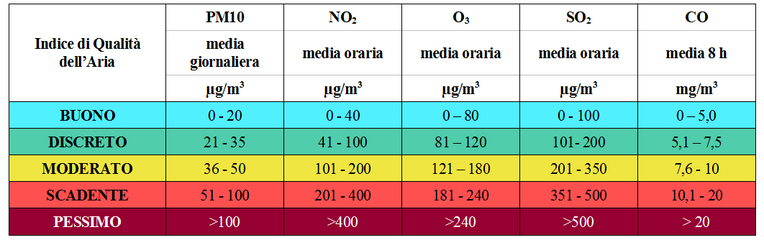

In [28]:
# aggiungiamo una colonna per l'indice di qualità dell'aria
display(Image(filename='../images/TABELLA_APPA.png'))

In [29]:
appa_comp_df = fs.add_eaqi(appa_comp_df)
appa_comp_df.head()

,station,date,hour,CO,NO2,O3,PM10,PM2.5,SO2,geometry,EAQI
0,A22 (Avio),2013-11-01,1,0.55,53.0,NaN,23.0,NaN,NaN,POINT (10.97043 45.74215),fair
1,A22 (Avio),2013-11-01,2,0.51,48.0,NaN,33.0,NaN,NaN,POINT (10.97043 45.74215),fair
2,A22 (Avio),2013-11-01,3,0.49,41.0,NaN,35.0,NaN,NaN,POINT (10.97043 45.74215),fair
3,A22 (Avio),2013-11-01,4,0.50,41.0,NaN,35.0,NaN,NaN,POINT (10.97043 45.74215),fair
4,A22 (Avio),2013-11-01,5,0.43,40.0,NaN,15.0,NaN,NaN,POINT (10.97043 45.74215),good


### SET
Introduciamo infine le misurazioni legate alla potenza elettrica. Intuitivamente correliamo il consumo di elettricità con la produzione di inquinanti atmosferici.
Vogliamo quindi innanzitutto introdurre la potenza per cella, mediarla su base oraria in modo da rispettare la separazione temporale dei dati APPA e capire infine come aggregare i dati sulla potenza in modo da assegnare a ciascuna stazione APPA un valore efficace di inquinanti

In [30]:
# creiamo i dataset e li sistemiamo un minimo
power_names = ['lineset', 'date_time', 'power']
pow_nov_df = pd.read_csv(data_path_raw / files_raw['SET-1'],names=power_names)
pow_dec_df = pd.read_csv(data_path_raw / files_raw['SET-2'],names=power_names)
pow_pos_df = pd.read_csv(data_path_raw / files_raw['SET-lines'])

# costruisco e concateno i dataframe con la potenza
lines_df = pd.concat([pow_nov_df, pow_dec_df], ignore_index=True)
lines_df = lines_df.sort_values(['lineset', 'date_time'])

date_time = pd.to_datetime(lines_df['date_time'])
date = date_time.dt.date
hour = date_time.dt.hour
lines_df['date'] = date
lines_df['hour'] = hour
lines_df = lines_df.drop(columns=['date_time'])

lines_df.head()

,lineset,power,date,hour
0,DG1000420,37.439999,2013-11-01,0
1,DG1000420,37.439999,2013-11-01,0
2,DG1000420,36.000000,2013-11-01,0
3,DG1000420,35.279999,2013-11-01,0
4,DG1000420,35.279999,2013-11-01,0


In [31]:
# dato che gli inquinanti atmosferici sono misurati su base oraria, medio la potenza su ciascuna ora. Per semplicità chiamo potenza ad una data ora la
# la potenza emessa dalle 00:00 di quell'ora alle 59:59 di quell'ora
lines_df = lines_df.groupby(['lineset', 'date', 'hour'])['power'].mean().reset_index()
lines_df.head()

,lineset,date,hour,power
0,DG1000420,2013-11-01,0,35.939999
1,DG1000420,2013-11-01,1,33.779998
2,DG1000420,2013-11-01,2,31.889998
3,DG1000420,2013-11-01,3,31.979998
4,DG1000420,2013-11-01,4,31.349998


In [32]:
# ogni linea elettrica distribuisce corrente elettrica su diverse celle. Mergiamo il df con la potenza per linea, con quello con il numero di ubicazioni 
# per cella a cui ogni linea fornisce energia. Assumendo un consumo uniforme per ubicazione, stimiamo poi quanta potenza venga effettivamente consumata in
# ciascuna cella.

sq_power_df = fs.get_square_power(pow_pos_df, lines_df)

sq_power_df.head()

,squareid,date,hour,power_square
0,155,2013-11-01,0,0.090551
1,155,2013-11-01,1,0.075594
2,155,2013-11-01,2,0.077797
3,155,2013-11-01,3,0.072870
4,155,2013-11-01,4,0.073739


In [33]:
# aggiungo la geometria alle celle grazie alla griglia

sq_power_df['geometry'] = sq_power_df['squareid'].map(grid_df.set_index('cellId')['geometry'])
sq_power_df.head()

,squareid,date,hour,power_square,geometry
0,155,2013-11-01,0,0.090551,"POLYGON ((10.91493 45.691, 10.92777 45.69079, ..."
1,155,2013-11-01,1,0.075594,"POLYGON ((10.91493 45.691, 10.92777 45.69079, ..."
2,155,2013-11-01,2,0.077797,"POLYGON ((10.91493 45.691, 10.92777 45.69079, ..."
3,155,2013-11-01,3,0.072870,"POLYGON ((10.91493 45.691, 10.92777 45.69079, ..."
4,155,2013-11-01,4,0.073739,"POLYGON ((10.91493 45.691, 10.92777 45.69079, ..."


#### Come facciamo ad assegnare un valore di potenza efficace a ciascuna stazione appa?
Assumndo gli inquinanti vengano prodotti a livello del terreno, vogliamo capire quanto riescano effettivamente a muoversi in atmosfera. In questo modo assegnamo a ciascuna stazione un raggio entro cui l'eventuale emissione di inquinanti può essere effettivamente rilevata dalla stazione stessa.
Leggendo online, sembra ci siano diversi modelli che possano descrivere la dispersione degli inquinanti nella bassa atmosfera.
Si veda: https://it.wikipedia.org/wiki/Modelli_di_dispersione_in_atmosfera
Studiare approfonditamente il fenomeno va ben oltre gli scopi di questo progetto. Assumiamo una descrizione approssimata e semplice della dispersione.

Trascurando la presenza del vento, i due principali vettori della dispersione sono il movimento browniano delle particelle in aria ed i moti turbolenti che si instaurano in presenza di gradienti termici. Leggendo in giro, sembra che il fenomeno browniano sia sostanzialmente trascurabile, portando a movimenti di solo qualche metro al giorno.

Il fenomeno dominante sono invece i moti turbolenti, che possono trasportare l'inquinante anche a diverse centinaia di metri nel giro di qualche ora.
In base al coefficiente di diffusione turbolenta K il trasporto può essere più o meno pronunciato. 
Per il raggio di diffusione, assumiamo un andamento temporale del tipo: r(t) = sqrt(6Kt), dove r è in metri e t in secondi. Chiaramente questo è un numero alla buona tirato fuori da uno studio veramente approssimativo, ma per il momento lo prendiamo come buone, verificando successivamente ad occhio che la zona coperta sia sufficiente.

In [34]:
# riprendiamo la posizione delle stazioni APPA
appa_pos = appa_pos[['station', 'geometry']]

# assegno le celle ad ogni stazione
# passiamo dalla notazione standard GPS alla notazione in metri
grid_df_mt = grid_df.set_crs('EPSG:4326').to_crs('EPSG:32632')

appa_pos = gpd.GeoDataFrame(data=appa_pos,geometry='geometry')
appa_pos_mt = appa_pos.set_crs('EPSG:4326').to_crs('EPSG:32632')

K = 1 # coefficiente di diffusione turbolenta - la nostra assunzione è abbastanza approssimativa

# creo un df che contenga la potenza efficace assegnata ad ogni stazione e ad ogni ora
final_power_df = fs.get_power_areas(appa_pos_mt, grid_df_mt, sq_power_df, K)
final_power_df['hour'] = final_power_df['hour'].astype(int)
final_power_df.head()

,station,date,hour,tot_area_power
23,A22 (Avio),2013-11-01,23,98.779135
24,A22 (Avio),2013-11-02,0,99.983828
25,A22 (Avio),2013-11-02,1,101.379504
26,A22 (Avio),2013-11-02,2,102.205106
27,A22 (Avio),2013-11-02,3,103.099904


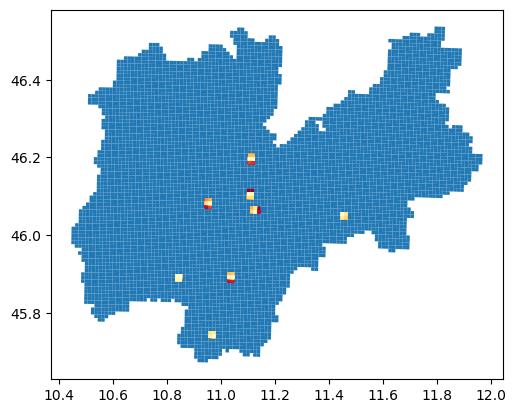

In [35]:
# le grandezze che abbiamo preso hanno senso? Gli inquinanti potrebbero muoversi di più?
# capiamo guardando sulla mappa

grid_df_crs = grid_df.set_crs('EPSG:4326').to_crs('EPSG:32632')
appa_pos_crs = appa_pos.set_crs('EPSG:4326').to_crs('EPSG:32632')

dfs = []
K = 1 # coefficiente di diffusione turbolenta - la nostra assunzione è abbastanza approssimativa

for h in range(24): # voglio l'impatto degli inquinanti entro un giorno
    radius = round(np.sqrt(6*K*h*3600) + 1) # distanza in m che assumiamo una particella possa percorrere in h ore
    # sommo 1 per sopperire a h = 0
    appa_buffer = appa_pos_crs
    appa_buffer[f'geometry_buffer_{radius}'] = appa_buffer.geometry.buffer(radius)
    appa_buffer = appa_buffer.set_geometry(f'geometry_buffer_{radius}')
    area_df = gpd.sjoin(appa_buffer,grid_df_crs,predicate='intersects',how='inner')
    area_df = area_df[['station', 'geometry', f'geometry_buffer_{radius}', 'cellId']]
    area_df = pd.merge(area_df,grid_df,on='cellId',how='left')
    area_df = gpd.GeoDataFrame(data=area_df,geometry='geometry_y')

    dfs.append(area_df)

cmap = plt.cm.YlOrRd

# coloro ogni zona da bianco a rosso a seconda della distanza dalla stazione APPA (ogni colore è assegnato ad una diversa ora di ritardo)
ax = grid_df.plot()
for h in range(23, -1, -1):
    dfs[h].plot(ax = ax,color=cmap(h / 24))

In [36]:
# confrontiamo con la mappa del comune per vedere effettivamente cosa stiamo veramente prendendo

# importiamo innanzitutto il dataframe con i confini amministrativi
with open(data_path_raw / files_raw['adm_reg']) as f:
    admin_json = json.load(f)

admin_df = gpd.GeoDataFrame(admin_json['features'])
admin_df['geometry'] = admin_df['geometry'].apply(shape)
admin_df['municipality'] = admin_df['properties'].apply(lambda x: x['comune'])
admin_df = gpd.GeoDataFrame(admin_df,geometry='geometry')
admin_df.head()

,type,properties,geometry,municipality
0,Feature,"{'pkuid': 3467, 'cod_rip': 2, 'cod_reg': 4, 'c...","POLYGON ((11.23686 45.9545, 11.2373 45.95449, ...",Folgaria
1,Feature,"{'pkuid': 3468, 'cod_rip': 2, 'cod_reg': 4, 'c...","POLYGON ((11.19112 46.5037, 11.19183 46.50402,...",Fondo
2,Feature,"{'pkuid': 3469, 'cod_rip': 2, 'cod_reg': 4, 'c...","POLYGON ((11.21929 46.12242, 11.22091 46.12267...",Fornace
3,Feature,"{'pkuid': 3470, 'cod_rip': 2, 'cod_reg': 4, 'c...","POLYGON ((11.30778 46.09674, 11.31344 46.09521...",Frassilongo
4,Feature,"{'pkuid': 3471, 'cod_rip': 2, 'cod_reg': 4, 'c...","POLYGON ((11.06351 46.02184, 11.07263 46.02202...",Garniga Terme


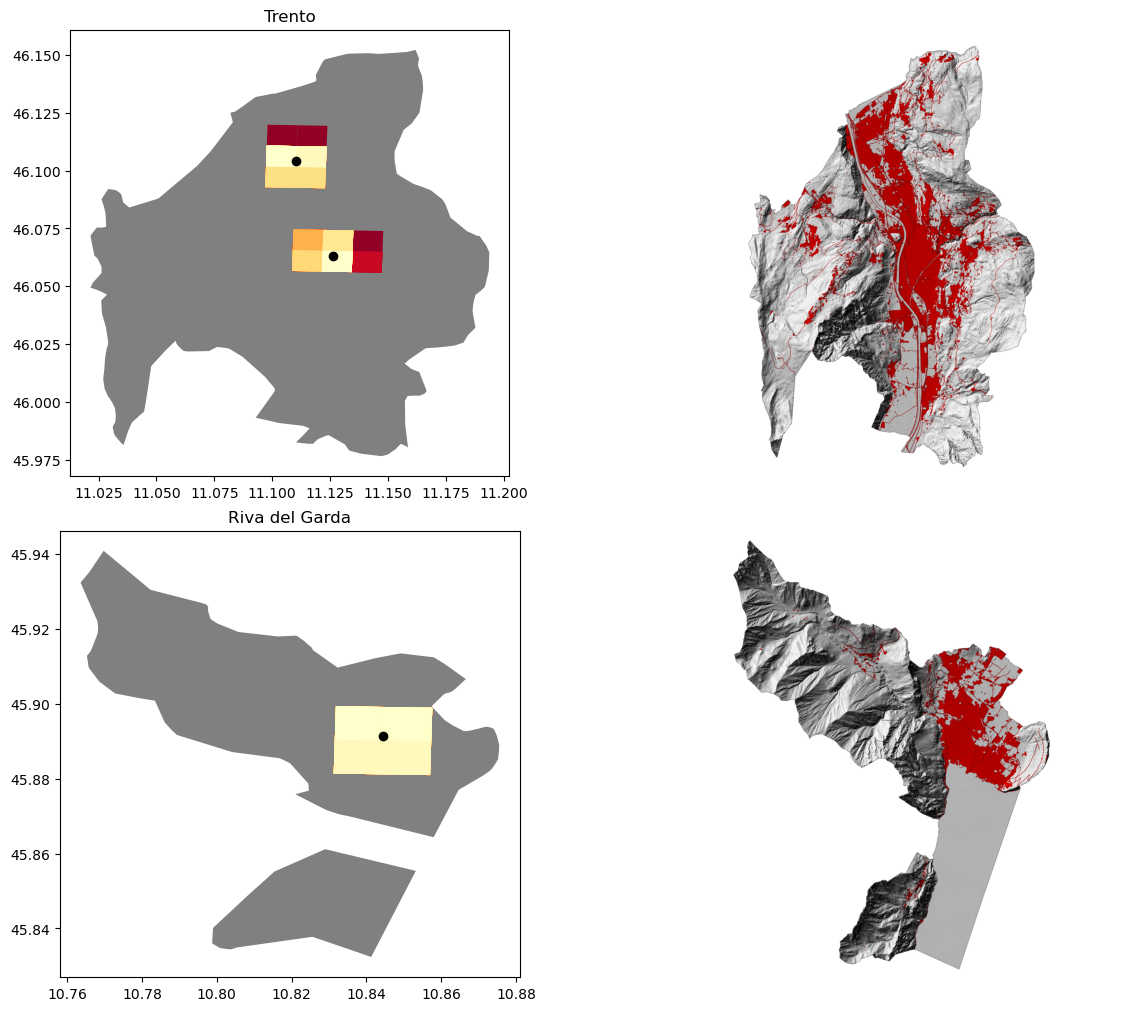

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

# Trento
ax = axes[0][0]
admin_df[admin_df['municipality'] == 'Trento'].plot(ax=ax,color='gray')
for h in range(23, -1, -1):
    dfs[h][(dfs[h]['station'] == 'Parco S. Chiara') | (dfs[h]['station'] == 'Via Bolzano')].plot(ax=ax,color=cmap(h / 24))
appa_pos[(appa_pos['station'] == 'Parco S. Chiara') | (appa_pos['station'] == 'Via Bolzano')].plot(ax=ax,color='black')
ax.set_title('Trento')

img = mpimg.imread('../images/Trento.png')
axes[0][1].imshow(img)
axes[0][1].axis('off')

# Riva del Garda
ax = axes[1][0]
admin_df[admin_df['municipality'] == 'Riva del Garda'].plot(ax=ax,color='gray')
for h in range(23, -1, -1):
    dfs[h][dfs[h]['station'] == 'Riva del Garda'].plot(ax=ax,color=cmap(h / 24))
appa_pos[appa_pos['station'] == 'Riva del Garda'].plot(ax=ax,color='black')
ax.set_title('Riva del Garda')

img = mpimg.imread('../images/Riva del Garda.png')
axes[1][1].imshow(img)
axes[1][1].axis('off')

plt.show()

Stiamo prendendo una parte considerevole di ciascun comune. Non penso che nell'assunzione di no vento le particelle inquinanti possano muoversi più di così.
Si tenga anche conto di come il Trentino sia particolarmente montuoso, per cui, si può notare dai due esempi, anche allargando l'area si andrebbero a comprendere prevalentemente montagne

### Creazione DataFrame completo
Dopo aver creato separatamente i DataFrame per gli inquinanti, per il meteo e per i consumi elettrici, uniamo infine i dati in un unico DataFrame da utilizzare poi nel training.

In [89]:
# assegnamo le rilevazioni meteo a quelle appa associando ai dati appa quelli delle stazioni meteo vicine
# assumiamo una distanza sensata entro cui il meteo non cambia in maniera incisiva (per lo meno la temperatura e le precipitazioni) sia entro 1km di raggio
m_df = gpd.GeoDataFrame(weather_df[['station','geometry']].drop_duplicates(), geometry='geometry')
a_df = gpd.GeoDataFrame(appa_comp_df[['station','geometry']].drop_duplicates(), geometry='geometry')

# passiamo alla geometria in metri
a_df = a_df.set_crs('EPSG:4326').to_crs(32632)
m_df = m_df.set_crs('EPSG:4326').to_crs(32632)

# NB: notiamo come, l'unica stazione appa che non ha stazioni meteo entro i 4000 metri è la stazione di Avio.
# per questa stazione la stazione meteo più vicina è a circa 6500 metri. Distanza che riteniamo troppo grande perché i dati meteo siano effettivamente affidabili.
# visto che questa stazione non era neanche nel dataframe fornito con il progetto, preferiamo escludere la stazione dallo studio.
# fissiamo quindi il raggio R a 4km, in modo che ogni stazione appa faccia riferimento ad una stazione meteo.

# creiamo l'area di influenza e assegnamo la stazione più vicina
R = 4000
a_df['geometry'] = a_df.geometry.buffer(R)
map_df = gpd.sjoin(m_df,a_df,predicate='within',how='inner')

# mergiamo i dataframe sulla base della stazione più vicina
appa_comp_df['station_weather'] = appa_comp_df['station'].map(map_df.set_index('station_right')['station_left'])

# escludiamo la stazione di Avio
appa_comp_df = appa_comp_df[appa_comp_df['station'] != 'A22 (Avio)']

# finiamo il merge
final_df = appa_comp_df.merge(weather_df,left_on=['station_weather','date','hour'],right_on=['station','date','hour'],suffixes=('_appa','_weather'))
final_df = final_df.T.drop_duplicates().T # si crea una colonna duplicata station_weather, togliamola

# aggiungo i dati sulla potenza dissipata
# correggo il formato della data, che se no li vede diversi
final_df['date'] = pd.to_datetime(final_df['date']).dt.date
final_power_df['date'] = pd.to_datetime(final_power_df['date']).dt.date

final_df = final_df.merge(final_power_df,left_on=['station_appa','date','hour'],right_on=['station','date','hour'],how='left')
final_df = final_df.dropna(subset='tot_area_power')
final_df = final_df.drop(columns='station')

# chiudo aggiungendo una colonna con il giorno della settimana
final_df['date'] = pd.to_datetime(final_df['date'])
final_df['week_day'] = final_df['date'].dt.weekday
final_df.head()

,station_appa,date,hour,CO,NO2,O3,PM10,PM2.5,SO2,geometry_appa,EAQI,station_weather,elevation,temperature,precipitation,winds_spd,winds_dir,geometry_weather,tot_area_power,week_day
22,Borgo Valsugana,2013-11-01,23,NaN,16.0,9.0,25.0,15.0,NaN,POINT (11.45389 46.05184),fair,T0392,410,10.0,0.0,NaN,NaN,POINT (11.47747769 46.05804607),921.457256,4
23,Borgo Valsugana,2013-11-02,1,NaN,14.0,14.0,25.0,17.0,NaN,POINT (11.45389 46.05184),fair,T0392,410,10.1,0.0,NaN,NaN,POINT (11.47747769 46.05804607),938.390584,5
24,Borgo Valsugana,2013-11-02,2,NaN,15.0,10.0,25.0,17.0,NaN,POINT (11.45389 46.05184),fair,T0392,410,10.0,0.0,NaN,NaN,POINT (11.47747769 46.05804607),940.862870,5
25,Borgo Valsugana,2013-11-02,3,NaN,12.0,16.0,25.0,18.0,NaN,POINT (11.45389 46.05184),fair,T0392,410,10.2,0.0,NaN,NaN,POINT (11.47747769 46.05804607),943.581445,5
26,Borgo Valsugana,2013-11-02,4,NaN,12.0,14.0,23.0,18.0,NaN,POINT (11.45389 46.05184),fair,T0392,410,10.0,0.0,NaN,NaN,POINT (11.47747769 46.05804607),941.596837,5


## Exploratory Data Analysis

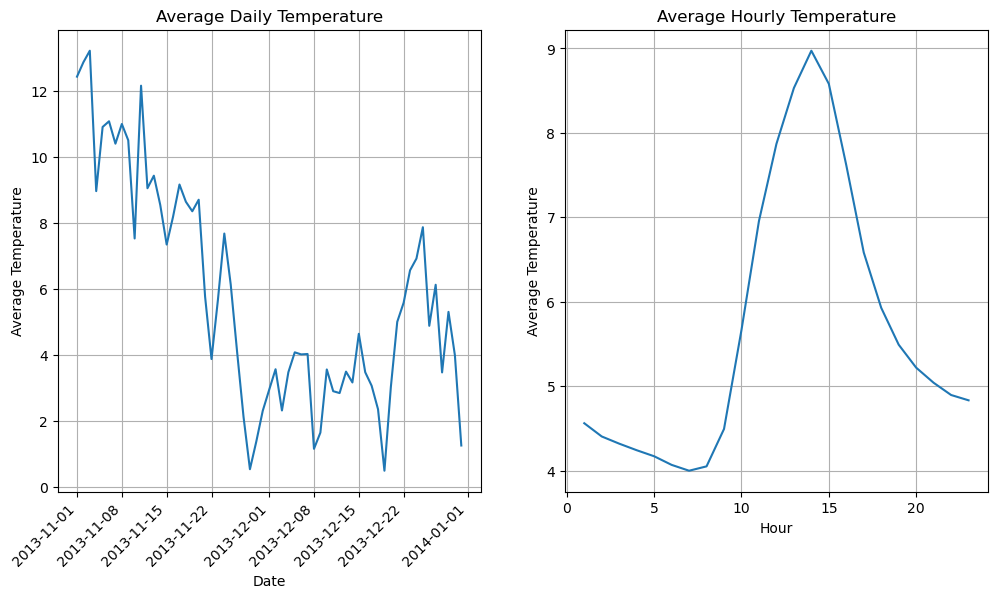

In [47]:
# Osserviamo l'andamento della temperatura in funzione dell'ora e del giorno:
hourly_temp = (final_df.groupby(['hour'])['temperature'].mean().reset_index())
daily_temp = (final_df.groupby(['date'])['temperature'].mean().reset_index())

plt.figure(figsize=(12,6))

plt.subplot(1, 2, 1)
plt.plot(daily_temp['date'], daily_temp['temperature'])
plt.xlabel('Date')
plt.ylabel('Average Temperature')
plt.title('Average Daily Temperature')
plt.xticks(rotation=45, ha='right')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hourly_temp['hour'], hourly_temp['temperature'])
plt.xlabel('Hour')
plt.ylabel('Average Temperature')
plt.title('Average Hourly Temperature')
plt.grid(True)

plt.show()

Chiaramente la temperatura decresce passando da Novembre a Dicembre e dimostra un chiaro trend nel corso della giornata, con un minimo alle 7 di mattina e un massimo alle due del pomeriggio. Nessuno di questi comportamenti ci sorprende.

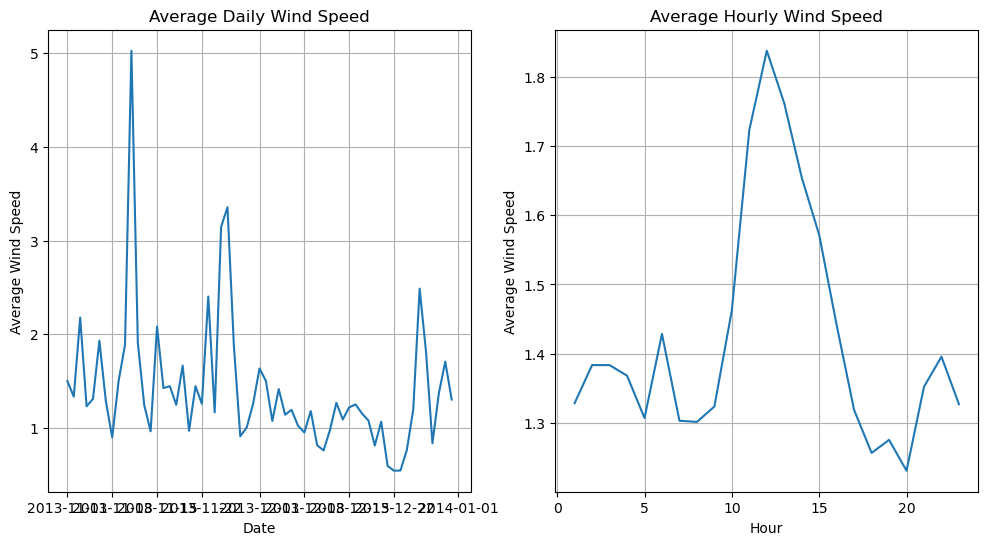

In [49]:
# Ci chiediamo se la velocità del vento segue un simile andamento
daily_wind = (final_df.groupby(['date'])['winds_spd'].mean().reset_index())
hourly_wind = (final_df.groupby(['hour'])['winds_spd'].mean().reset_index())

plt.figure(figsize=(12,6))

plt.subplot(1, 2, 1)
plt.plot(daily_wind['date'], daily_wind['winds_spd'])
plt.xlabel('Date')
plt.ylabel('Average Wind Speed')
plt.title('Average Daily Wind Speed')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(hourly_wind['hour'], hourly_wind['winds_spd'])
plt.xlabel('Hour')
plt.ylabel('Average Wind Speed')
plt.title('Average Hourly Wind Speed')
plt.grid(True)

plt.show()

Non osserviamo un andamento chiaro nell'andamento della velocità del vento nel periodo studiato. Tuttavia appare chiaro che la velocità del vento è maggiore tra le 10 e le 16. Questo è imputabile al Sole che splende maggiormente in quell'orario, riscaldando l'atmosfera e di conseguenza aumentando l'energia cinetica delle molecole e incrementando le turbolenze.

In [ ]:
# Verifichiamo se la concentrazione dei vari inquinanti esprime una dipendenza dall'orario (probabile) o dal giorno (possibile)
pols = ['SO2', 'NO2', 'CO', 'O3', 'PM10', 'PM2.5']

#plt.figure(figsize=(12,30))
#
## AGGIUNGERE ANALISI SETTIMANALE
#
#i = 0
#
#for p in pols:
#    daily_p = (final_df.groupby(['Data'])[p].mean().reset_index())
##   weekly_p = (final_df.groupby(['Data'])[p].mean().reset_index())
#    hourly_p = (final_df.groupby(['Ora'])[p].mean().reset_index())
#
#    plt.subplot(6, 3, 3*i+1)
#    plt.plot(daily_p['Data'], daily_p[p])
#    plt.xlabel('Date')
#    plt.ylabel('Average Concentration of ' + p + 'in µg/mc')
#    plt.title('Average Daily Concentration of ' + p)
#    plt.grid(True)
#
#    # qui ci andrebbe quella settimanale
#
#    plt.subplot(6, 3, 3*i+3)
#    plt.plot(hourly_wind['Ora'], hourly_p[p])
#    plt.xlabel('Hour')
#    plt.ylabel('Average Concentration of ' + p + 'in µg/mc')
#    plt.title('Average Hourly Concentration of ' + p)
#    plt.grid(True)
#    
#    i += 1
#
#del i

# NOTA: per la qualità dell'aria fare solo andamento orario e usare istogramma con 1 bin per ogni livello dell'EAQI 

#capiamo se li vogliamo effettivamente usare oppure no, sono un po' tanti grafici

Da questi grafici emergono andamenti poco chiari per le concentrazioni di inquinanti nel corso dei due mesi analizzati. D'altra parte, giornalmente le concentrazioni seguono trend che appaiono molto simili, ad eccezione dell'Ozono che appare seguire il percorso inverso. Sovrapponiamo quindi i dati per i diversi inquinanti in modo da poterli confrontare meglio 


QUANDO VIENE FATTA AGGIUNGERE DESCRIZIONE DATI SETTIMANALI

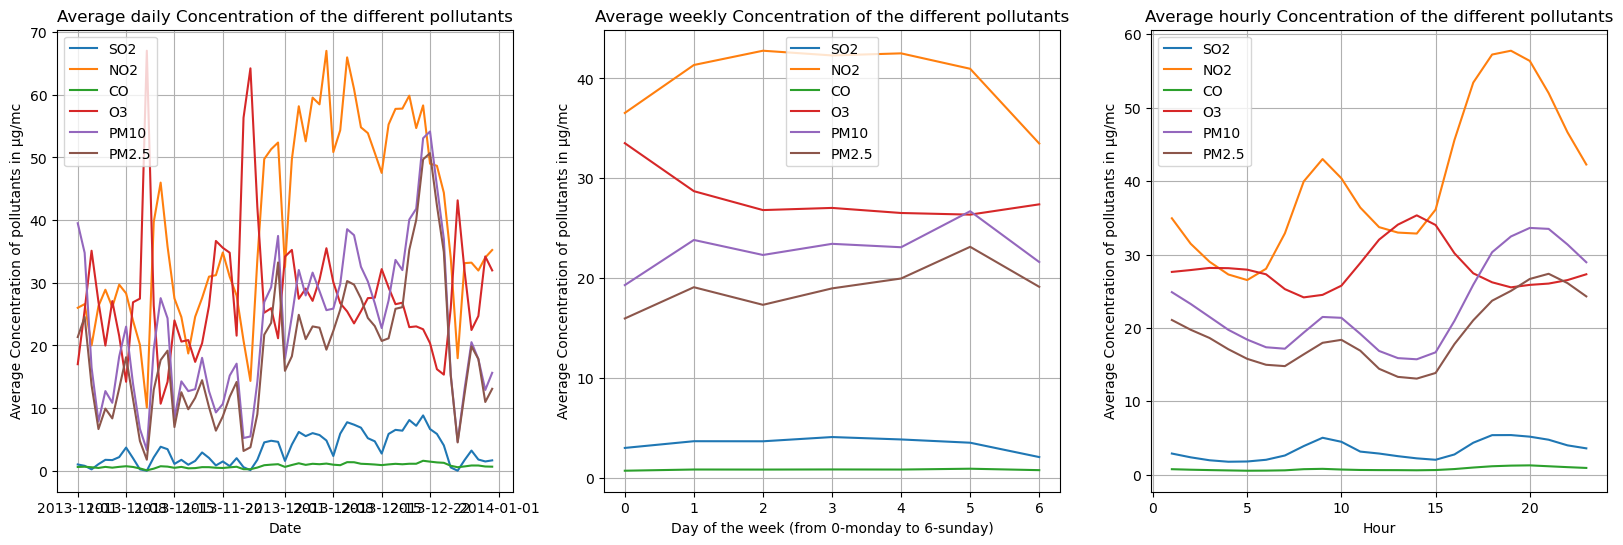

In [81]:
# Sono indeciso su questa cella, probabilente la rimuoverò

pols = ['SO2', 'NO2', 'CO', 'O3', 'PM10', 'PM2.5']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
ax1, ax2, ax3 = axes

for p in pols:
    daily_p = (final_df.groupby(['date'])[p].mean().reset_index())
    weekly_p = (final_df.groupby(['week_day'])[p].mean().reset_index())
    hourly_p = (final_df.groupby(['hour'])[p].mean().reset_index())

    ax1.plot(daily_p['date'], daily_p[p])
    ax2.plot(weekly_p['week_day'], weekly_p[p])
    ax3.plot(hourly_p['hour'], hourly_p[p])

ax1.set_xlabel('Date')
ax1.set_ylabel('Average Concentration of pollutants in µg/mc')
ax1.set_title('Average daily Concentration of the different pollutants')
ax1.legend(pols)
ax1.grid(True)

ax2.set_xlabel('Day of the week (from 0-monday to 6-sunday)')
ax2.set_ylabel('Average Concentration of pollutants in µg/mc')
ax2.set_title('Average weekly Concentration of the different pollutants')
ax2.legend(pols)
ax2.grid(True)

ax3.set_xlabel('Hour')
ax3.set_ylabel('Average Concentration of pollutants in µg/mc')
ax3.set_title('Average hourly Concentration of the different pollutants')
ax3.legend(pols)
ax3.grid(True)

plt.show()

È difficile confrontare accuratamente il comportamento dei diversi inquinanti poiché appartengono ad ordini di grandezza differenti, in particolar modo il monossido di carbonio, quindi disegnamo di ciascuno l'andamento in scala rispetto al proprio massimo

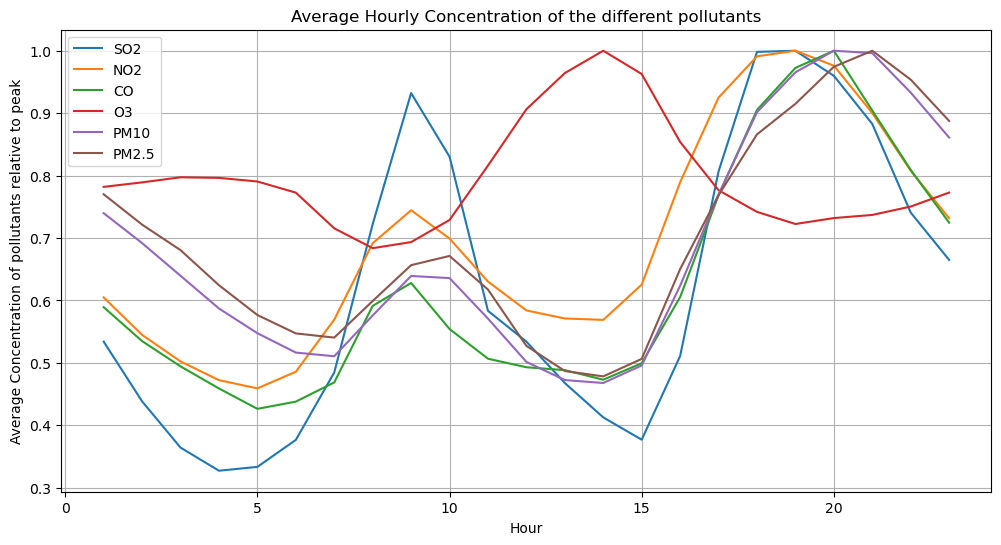

In [83]:
plt.figure(figsize=(12,6))

for p in pols:
    hourly_p = (final_df.groupby(['hour'])[p].mean().reset_index())
    hourly_p[p] = hourly_p[p] / max(hourly_p[p])
    plt.plot(hourly_p['hour'], hourly_p[p])


plt.xlabel('Hour')
plt.ylabel('Average Concentration of pollutants relative to peak')
plt.title('Average Hourly Concentration of the different pollutants')
plt.legend(pols)
plt.grid(True)

Appare chiaro che, ad eccezione dell'Ozono (che segue un trend opposto) tutti gli inquinanti si comportano allo stesso modo, esibendo alte concentrazioni attorno alle 9 di mattina  e tra le 7 e le 9 di sera mentre l'aria è più pulita attorno alle 6 di mattina e alle 2 del pomeriggio. Questo comportamento così evidente è sensato poiché questi materiali inquinanti sono prodotti principalmente da attività umane e, pertanto, è sensato che seguano i ritmi quotidiani della società.

Tracciamo anche l'andamento della qualità dell'aria al variare dell'ora disegnando un istogramma.

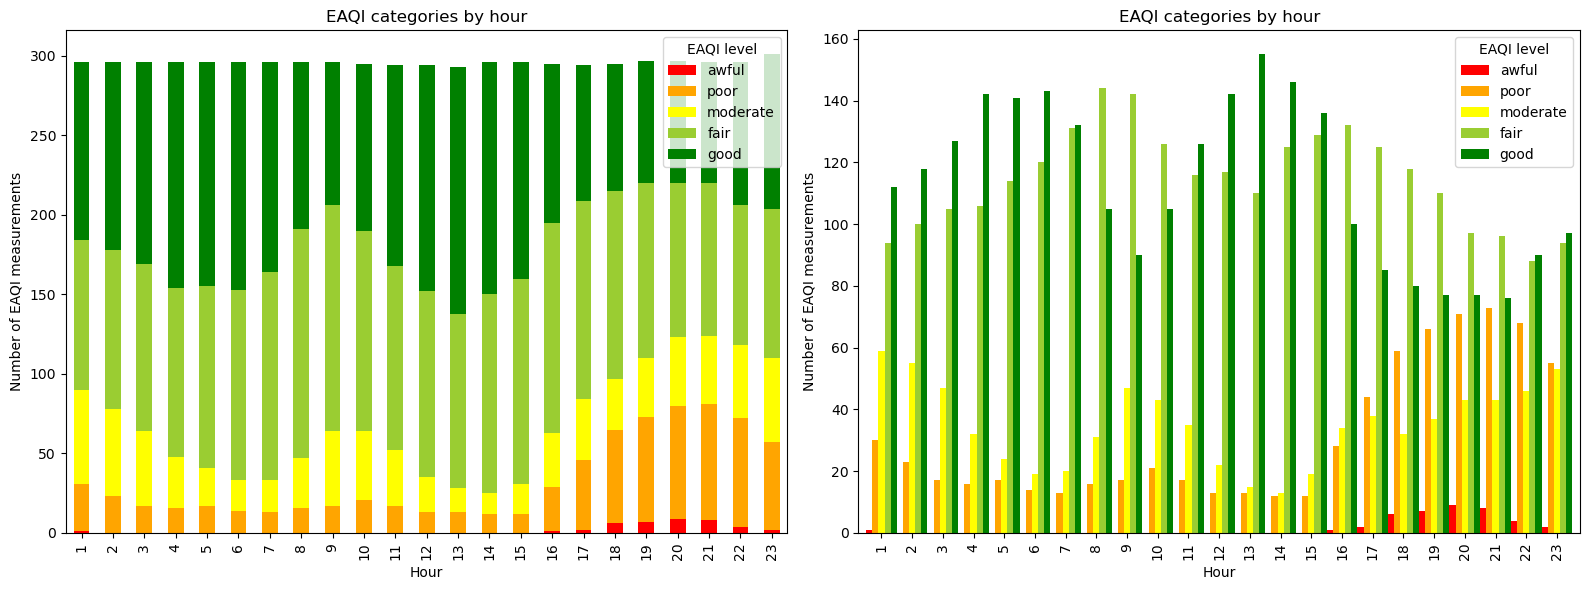

In [90]:
EAQI_ORDER = {'good': 4, 'fair': 3, 'moderate': 2, 'poor': 1, 'awful': 0}

# we don't want to alter our original dataframe
histogram_df = final_df.copy()

# the data must be presented in a consistent order and with intuitive color
category_order = ['awful', 'poor', 'moderate', 'fair', 'good']
colors = {'good': 'green', 'fair': 'yellowgreen', 'moderate': 'yellow', 'poor': 'orange', 'awful': 'red'}

histogram_df['EAQI'] = pd.Categorical(histogram_df['EAQI'], categories=category_order, ordered=True)

# Count occurrences for each hour and EAQI category
counts = (final_df.groupby(['hour', 'EAQI']).size().unstack(fill_value=0))
counts = counts[category_order]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

counts.plot(kind='bar', stacked=True, color=[colors[c] for c in category_order], ax=axes[0])
counts.plot(kind='bar', stacked=False, color=[colors[c] for c in category_order], width = 1, ax = axes[1])


axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Number of EAQI measurements')
axes[0].set_title('EAQI categories by hour')
axes[0].legend(title='EAQI level')

axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Number of EAQI measurements')
axes[1].set_title('EAQI categories by hour')
axes[1].legend(title='EAQI level')

plt.tight_layout()
plt.show()

Questi grafici indicano che la qualità dell'aria è migliore attorno alle 6 e alle 14 mentre peggiora significativamente tra le 20 e le 21.

Studiamo ora le correlazioni tra le varie feature del nostro dataframe, in modo da capire quali sono collegate maggiormente.

<Axes: >

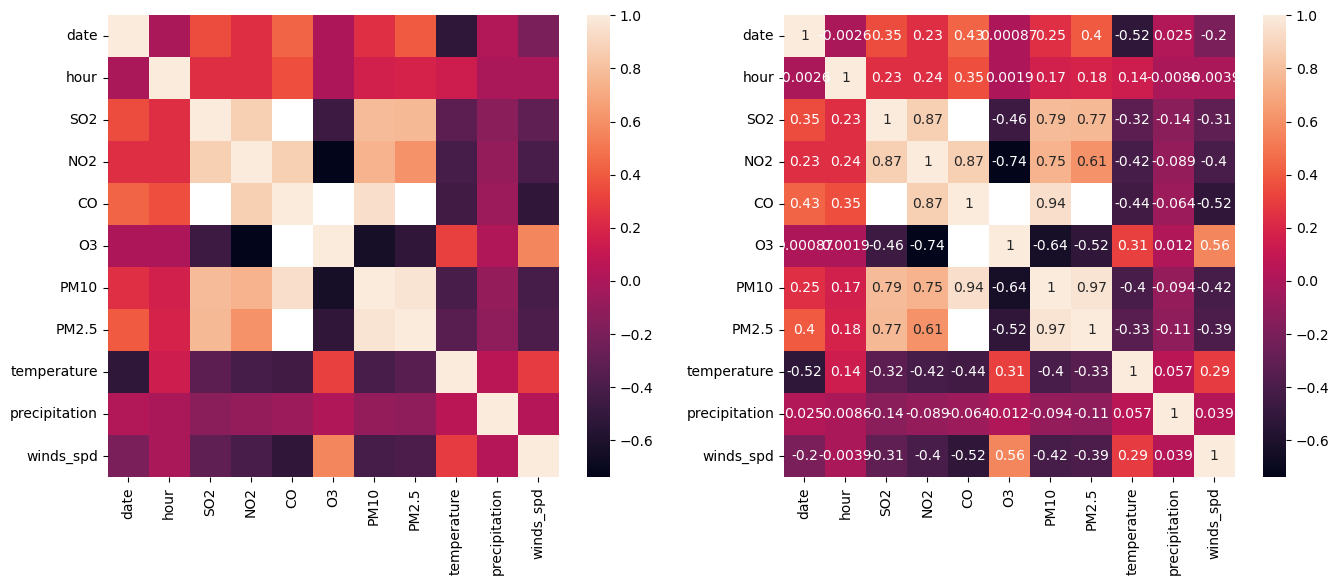

In [93]:
# c'è correlazione tra elevation - temperature - precipitation - wind - pollutants? 

corr_df = final_df.copy()

# cambiamo la data in un intero che va da 0 (2013-11-01) a 60 (2013-12-31)
corr_df['date'] = corr_df['date'].apply(fs.datetime_to_int)

analyzed_features = ['date', 'hour', 'SO2', 'NO2', 'CO', 'O3', 'PM10', 'PM2.5', 'temperature', 'precipitation', 'winds_spd']

# NOTA: QUANDO CI SARANNO AGGIUNGERE ASSOLUTAMENTE ELEVAZIONE E CONSUMI ELETTRICI

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.heatmap(corr_df[analyzed_features].corr(), ax=axes[0])
plt.subplot(1, 2, 2)
sns.heatmap(corr_df[analyzed_features].corr(), annot=True, ax=axes[1])

La matrice di correlazione indica alcuni trend interessanti:
-  Le concentrazioni di quasi tutti gli inquinanti (l'ozono è l'unica eccezione) crescono con il passare dei giorni.
-  L'ora esibisce correlazioni deboli con tutte le grandezze, nonostante sia evidente dagli scorsi grafici. Questo è dovuto al fatto che la correlazione di Pearson è utile per trovare trend lineari ma poco adatta a studiare dati come quelli orari che devono per forza di cose esibire una periodicità (il valore alle 24 è l'ultimo ma anche precedente al dato dell'1).
-  Nel quadrato di dati relativi agli inquinanti, sono presenti alcuni buchi, questo è indice del fatto che non tutte le stazioni APPA registrano dati per tutti gli inquinanti. Per alcune coppie di inquinanti, infatti, non è presente una stazione che li registri entrambi e, pertanto, non è possibile stabilire una correlazione.
-  Ad eccezione dell'ozono, tutti gli inquinanti sono fortemente correlati positivamente tra loro mentre l'ozono mostra una forte anticorrelazione rispetto agli altri. Questo è perfettamente in accordo con il grafico tracciato prima.
-  Vediamo una forte anticorrelazione tra la data e la temperatura. Questo è dovuto al periodo dell'anno analizzato (fine dell'autunno e inizio dell'inverno) e la correlazione sarebbe probabilmente nulla (o leggermente positiva dato il cambiamento climatico) se considerassimo un anno intero. Lo stesso discorso vale probabilmente anche per la velocità del vento.
-  Temperatura e velocità del vento sono correlate positivamente. Questo è imputabile al maggiore movimento delle particelle calde che risulta in più turbolenze e quindi venti più intensi.
-  È chiara l'anticorrelazione tra temperatura e velocità del vento da una parte e inquinanti dall'altra. Come sopra, l'ozono si muove in controtendenza rispetto agli altri inquinanti.
-  Le precipitazioni appaiono indipendenti rispetto a tutte le altre grandezze analizzate.

AGGIUNGERE COMMENTO SU ELETTRICITÀ E ELEVAZIONE

Come accennato sopra, le precipitazioni appaiono indipendenti rispetto a tutte le altre grandezze analizzate. Questo differisce 